In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

fileName = "./data/ModelsResults.xlsx"  # If it's in the current directory
sheetName = "staticOriginalResults"
limit = 15
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2).iloc[:limit, :]
df

,Model,Compression,Size (MB),BLEU,ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.731842,42.00,64.55,60.87,64.91,61.32,66.51,62.86,61.87,56.28
1,pythia-70M,8-bit,122.126906,41.39,64.53,60.86,64.80,61.20,66.49,62.87,61.86,56.32
2,pythia-70M,4-bit,113.771074,39.21,63.36,60.44,63.21,60.40,65.66,62.54,58.66,54.29
3,pythia-160M,Original,649.341186,42.49,65.70,61.64,65.59,61.57,67.44,63.55,63.95,58.17
4,pythia-160M,8-bit,240.116642,42.31,65.66,61.57,65.52,61.46,67.41,63.50,63.82,58.10
5,pythia-160M,4-bit,202.650482,40.60,64.50,61.12,64.19,60.90,66.68,63.27,59.69,55.09
6,pythia-410M,Original,1621.430000,43.51,67.41,62.69,67.52,62.66,68.87,64.42,67.11,61.24
7,pythia-410M,8-bit,509.700000,43.61,67.40,62.69,67.50,62.67,68.86,64.40,67.13,61.23
8,pythia-410M,4-bit,376.750000,42.41,65.67,61.91,65.96,61.92,67.73,63.88,60.39,55.77
9,pythia-1B,Original,4047.192000,44.18,68.99,63.86,69.07,63.93,70.29,65.54,68.34,63.68


### helper function

In [2]:
def generate_graphs(taskPerformance, MIA_attack, MIA_score, i):
    # Define styles
    model_order = ['pythia-70M', 'pythia-160M', 'pythia-410M', 'pythia-1B', 'pythia-1.4B']
    short_names = {
        'pythia-70M': 'P-70M',
        'pythia-160M': 'P-160M',
        'pythia-410M': 'P-410M',
        'pythia-1B': 'P-1B',
        'pythia-1.4B': 'P-1.4B'
    }

    # Color scheme and patterns for models
    model_styles = {
        'pythia-70M': {'color': "#0d8be5", 'pattern': '////'},
        'pythia-160M': {'color': "#ff7f0e", 'pattern': '....'},
        'pythia-410M': {'color': "#2ca02c", 'pattern': 'xxxx'},
        'pythia-1B': {'color': "#ef1010", 'pattern': '++++'},
        'pythia-1.4B': {'color': "#9467bd", 'pattern': '----'}
    }
    
    # Marker styles by compression type
    compression_markers = {
        'Original': {'marker': 'o', 'size': 100},
        '8-bit': {'marker': 's', 'size': 80},
        '4-bit': {'marker': '^', 'size': 80}
    }
    
    compression_order = ['Original', '8-bit', '4-bit']
    serials = ['a)', 'b)', 'c)', 'd)']
    
    # Create figure with 1 row, 4 columns
    fig, axes = plt.subplots(1, 4, figsize=(24, 8))
    plt.subplots_adjust(top=0.75, bottom=0.25, wspace=0.4)
    
    # Formatting for all axes
    for ax in axes:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, linestyle=':', alpha=0.3)
    
    # First three subplots (one per compression type)
    for idx, compression in enumerate(compression_order):
        ax = axes[idx]
        
        # Plot all models with current compression's marker
        for model in model_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                ax.scatter(
                    subset[taskPerformance], subset[MIA_score],
                    c=model_styles[model]['color'],
                    marker=compression_markers[compression]['marker'],
                    s=compression_markers[compression]['size'],
                    alpha=0.8,
                    edgecolors='k',
                    linewidths=1.5,
                    hatch=model_styles[model]['pattern']
                )
        
        # Regression line
        sns.regplot(
            x=taskPerformance, y=MIA_score, 
            data=df[df['Compression'] == compression],
            scatter=False, ci=95,
            ax=ax,
            line_kws={
                'color': 'black', 
                'alpha': 0.4, 
                'linestyle': '--',
                'linewidth': 2
            }
        )
        
        # Correlation annotation
        corr = df[df['Compression'] == compression][taskPerformance].corr(
               df[df['Compression'] == compression][MIA_score])
        
        ax.annotate(
            f'r = {corr:.3f}', 
            xy=(0.65, 0.15), 
            xycoords='axes fraction',
            fontsize=20,
            bbox=dict(boxstyle='round', alpha=0.3, edgecolor='gray')
        )

        ax.set_title(f'{serials[idx]} {compression}', fontsize=20)
        ax.set_xlabel('CodeBLEU Score (%)', fontsize=20)
        if idx == 0:
            ax.set_ylabel(f'{MIA_score.split(".")[0]} Score({MIA_attack}) (%)', fontsize=20)

    # Fourth subplot (all compressions together)
    ax = axes[3]
    for compression in compression_order:
        for model in model_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                ax.scatter(
                    subset[taskPerformance], subset[MIA_score],
                    c=model_styles[model]['color'],
                    marker=compression_markers[compression]['marker'],
                    s=compression_markers[compression]['size'],
                    alpha=0.8,
                    edgecolors='k',
                    linewidths=1.5,
                    hatch=model_styles[model]['pattern'],
                    label=f"{short_names[model]} {compression}"
                )
    
    # Regression line for all data
    sns.regplot(
        x=taskPerformance, y=MIA_score, data=df,
        scatter=False, ci=95,
        ax=ax,
        line_kws={
            'color': 'black', 
            'alpha': 0.4, 
            'linestyle': '--',
            'linewidth': 2
        }
    )
    
    # Overall correlation
    corr = df[taskPerformance].corr(df[MIA_score])
    ax.annotate(
        f'r = {corr:.3f}', 
        xy=(0.65, 0.15), 
        xycoords='axes fraction',
        fontsize=20,
        bbox=dict(boxstyle='round', alpha=0.3, edgecolor='gray')
    )

    ax.set_title('d) All Models and Compressions', fontsize=20)
    ax.set_xlabel('CodeBLEU Score (%)', fontsize=20)
    
    # Create and position legends
    model_legend_elements = [
        plt.Rectangle(
            (0,0), 1, 1, 
            fc=model_styles[model]['color'],
            hatch=model_styles[model]['pattern'],
            edgecolor='k',
            label=short_names[model]
        ) for model in model_order
    ]
    
    compression_legend_elements = [
        Line2D(
            [0], [0], 
            marker=compression_markers[comp]['marker'], 
            color='w',
            markerfacecolor='gray',
            markersize=8,
            markeredgecolor='k',
            label=comp
        ) for comp in compression_order
    ]
    
    # Add legends below the plots
    fig.legend(
        handles=model_legend_elements,
        title='Models (P=Pythia)',
        loc='lower center',
        bbox_to_anchor=(0.34, .9),
        ncol=5,
        fontsize=20,
        title_fontsize=20,
        framealpha=0.9
    )
    
    fig.legend(
        handles=compression_legend_elements,
        title='Compression Types',
        loc='lower center',
        bbox_to_anchor=(0.8, .9),
        ncol=3,
        fontsize=20,
        title_fontsize=20,
        framealpha=0.9
    )
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0.1, 1, 0.9])
    plt.savefig(f'./output/RQ3.{i}.pdf', dpi=350, bbox_inches='tight')
    plt.show()
    plt.close()
#generate_graphs("BLEU", "ZLIB", "ROC_AUC", 3)

### graph generate

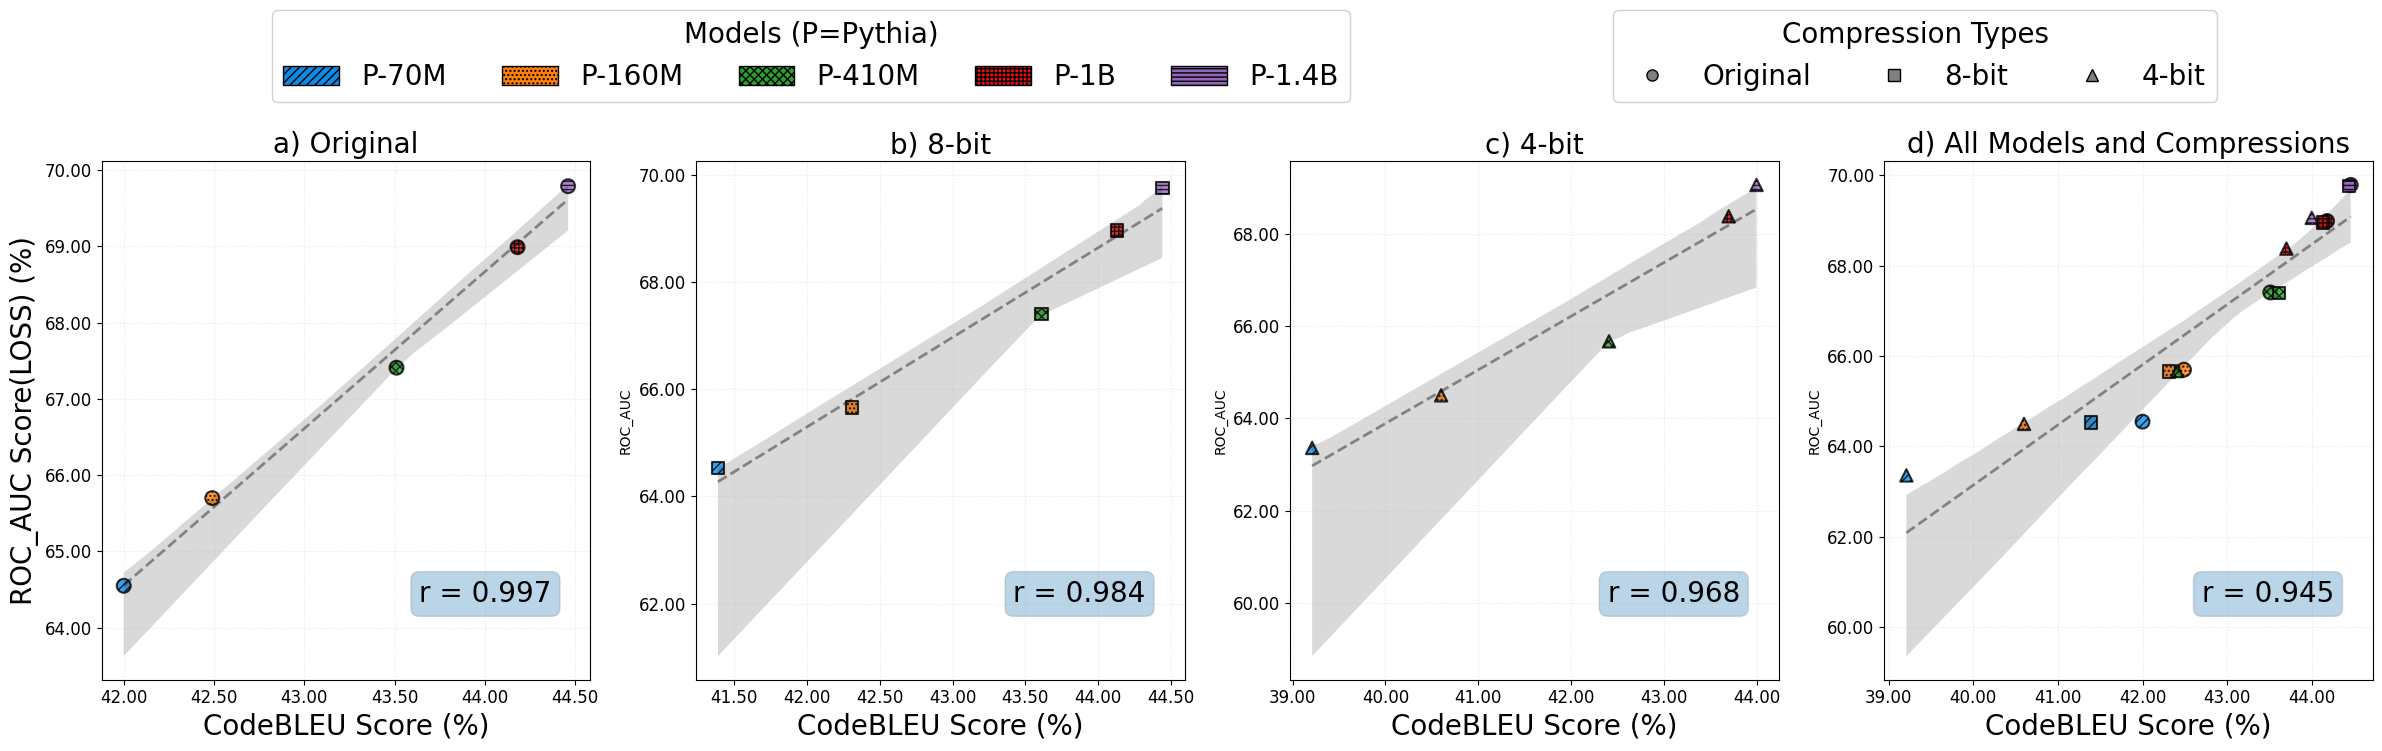

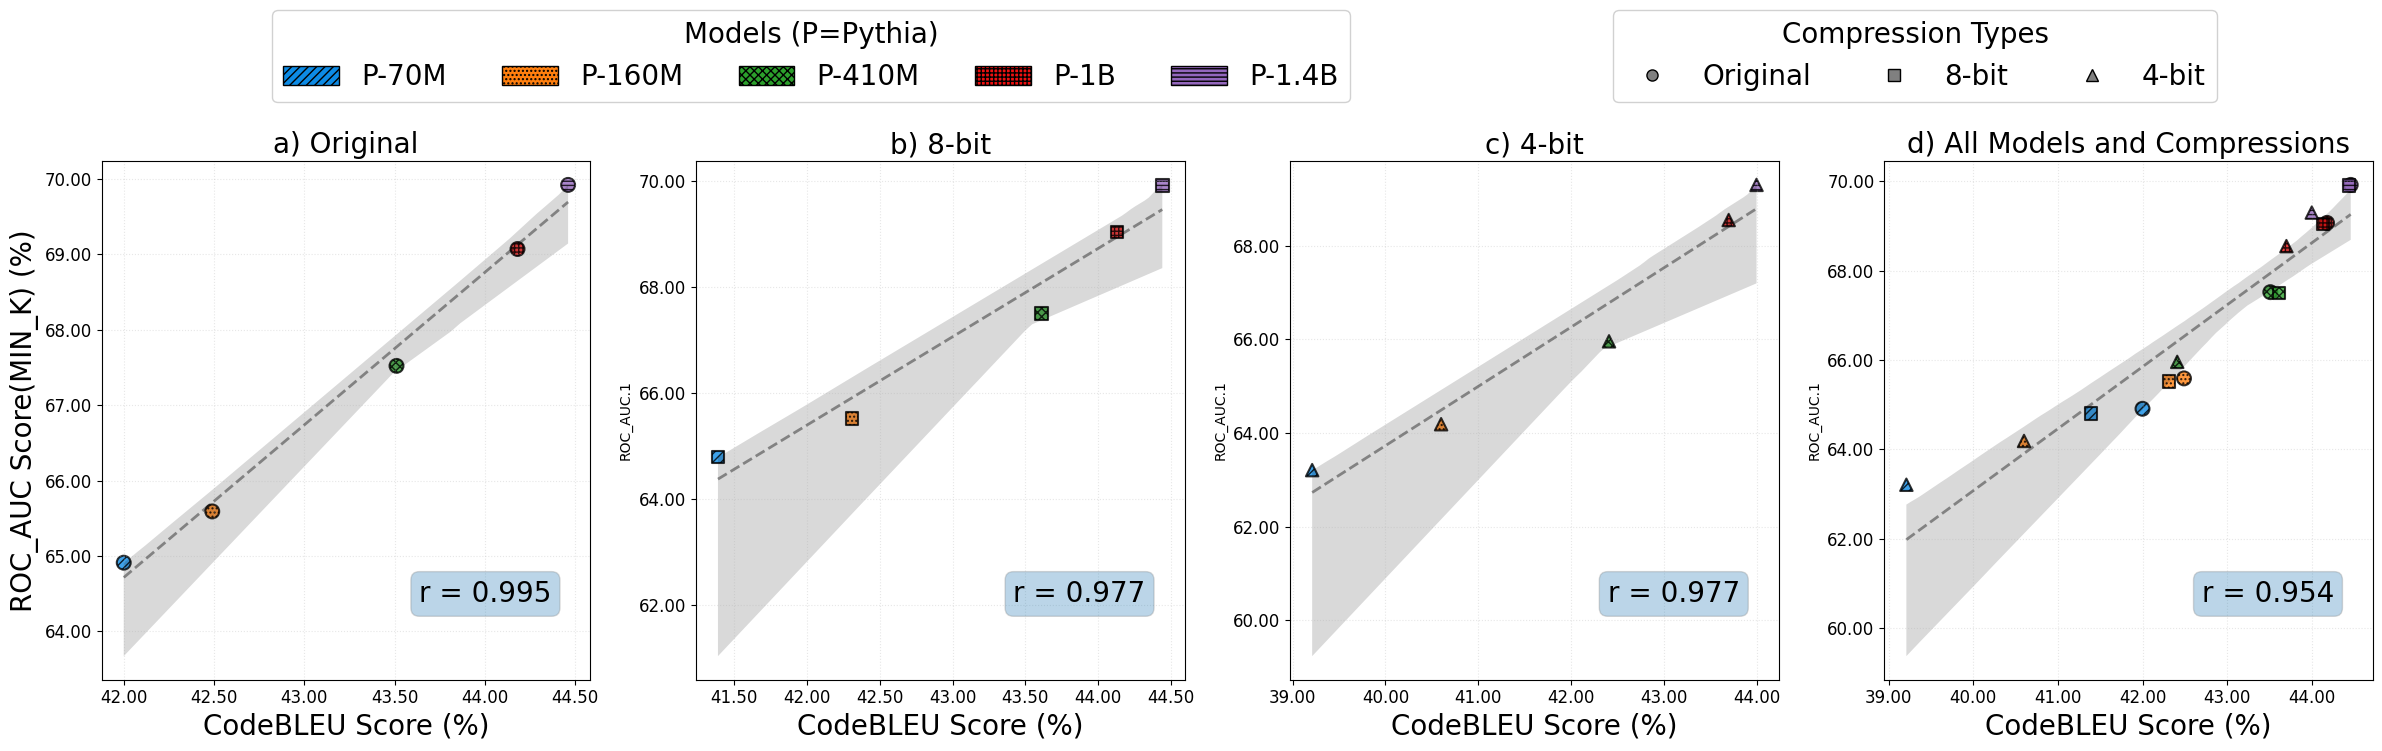

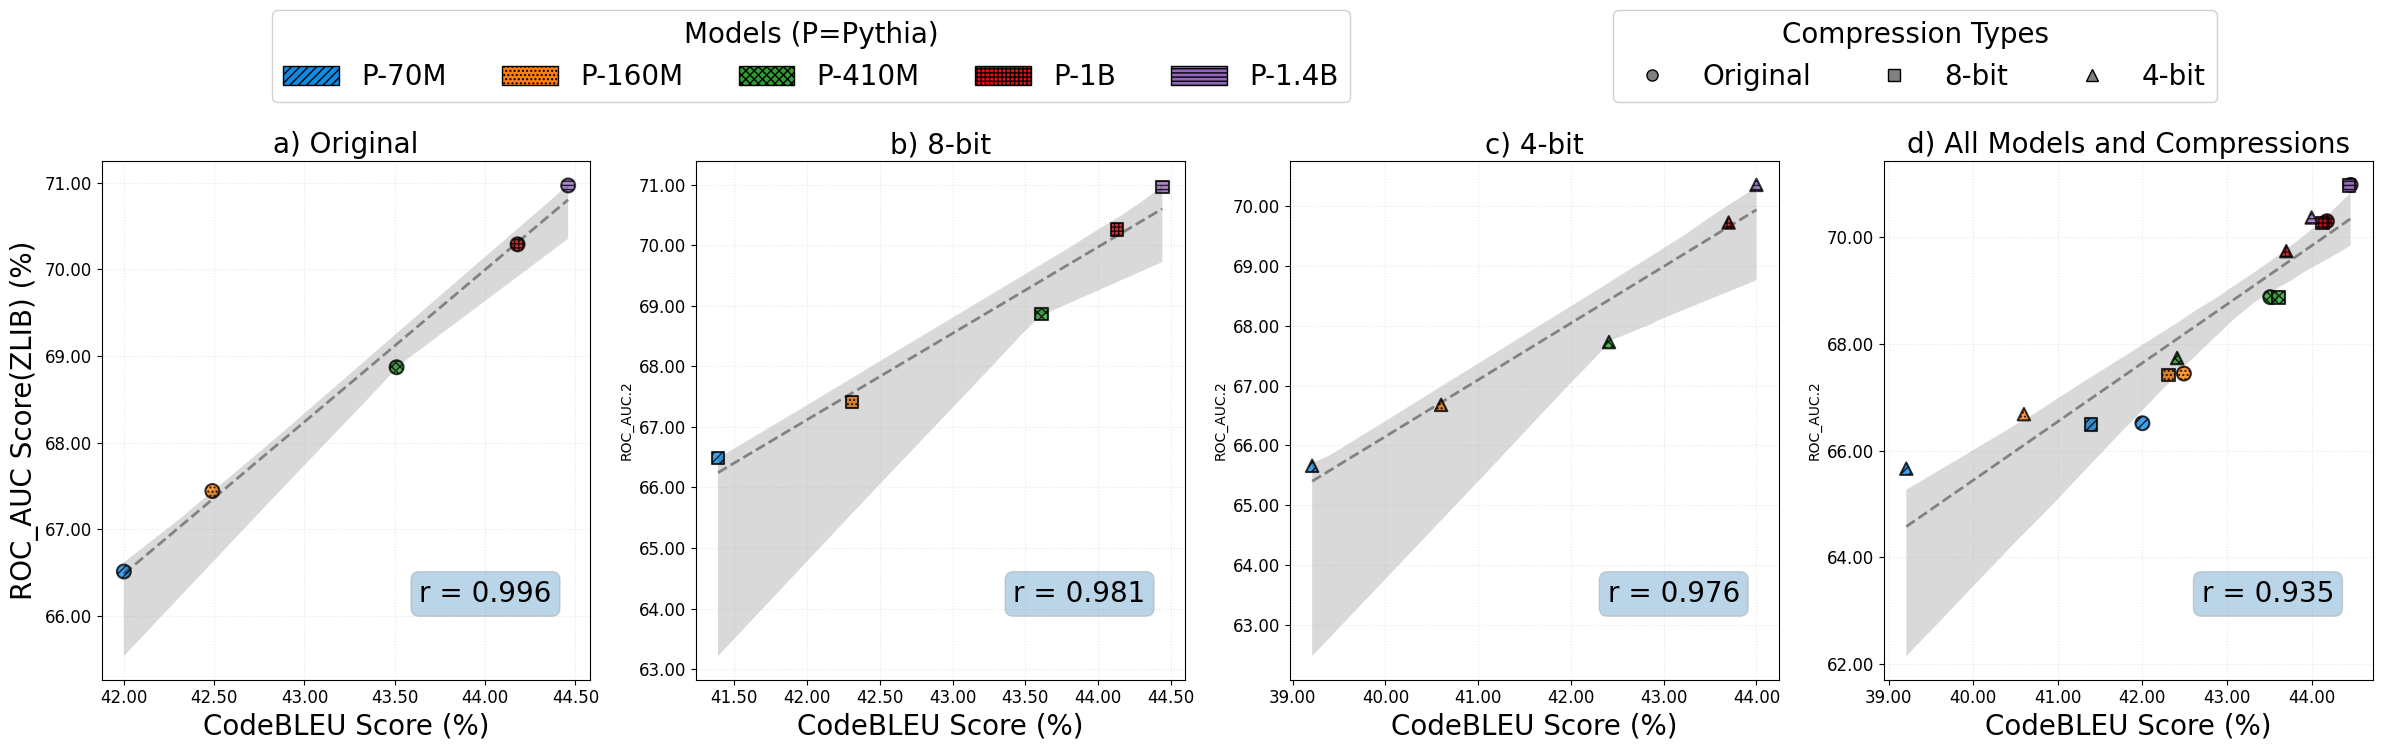

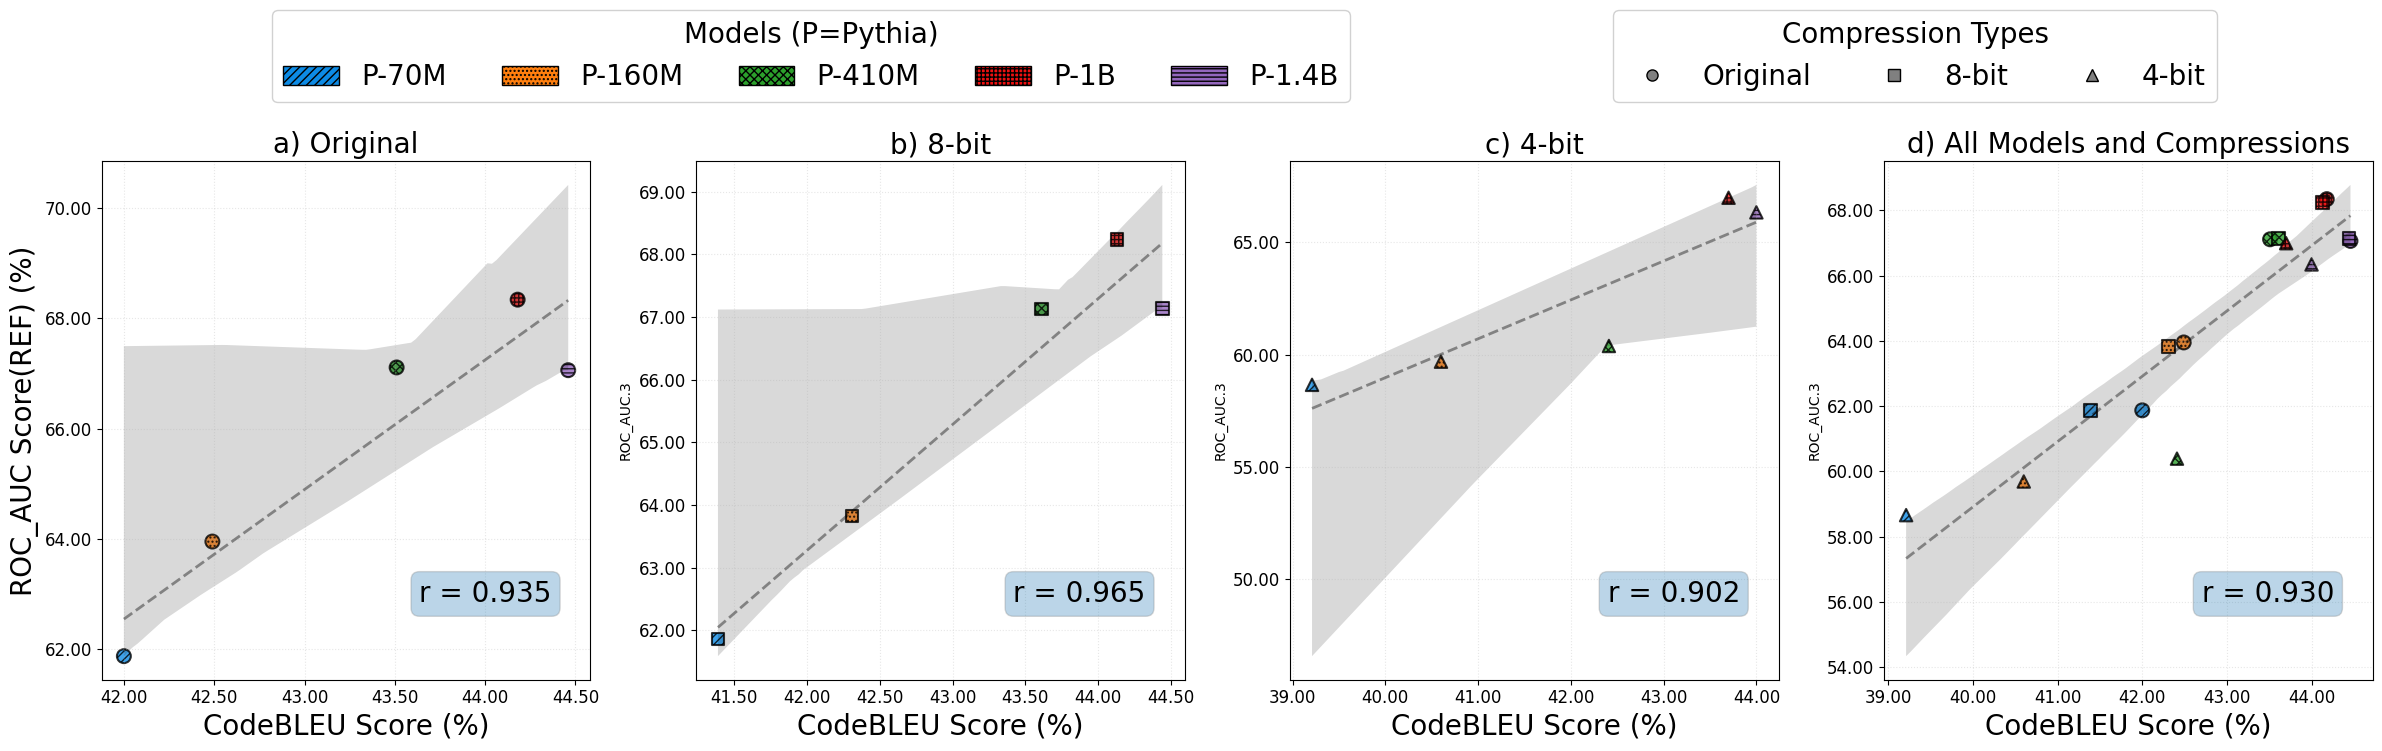

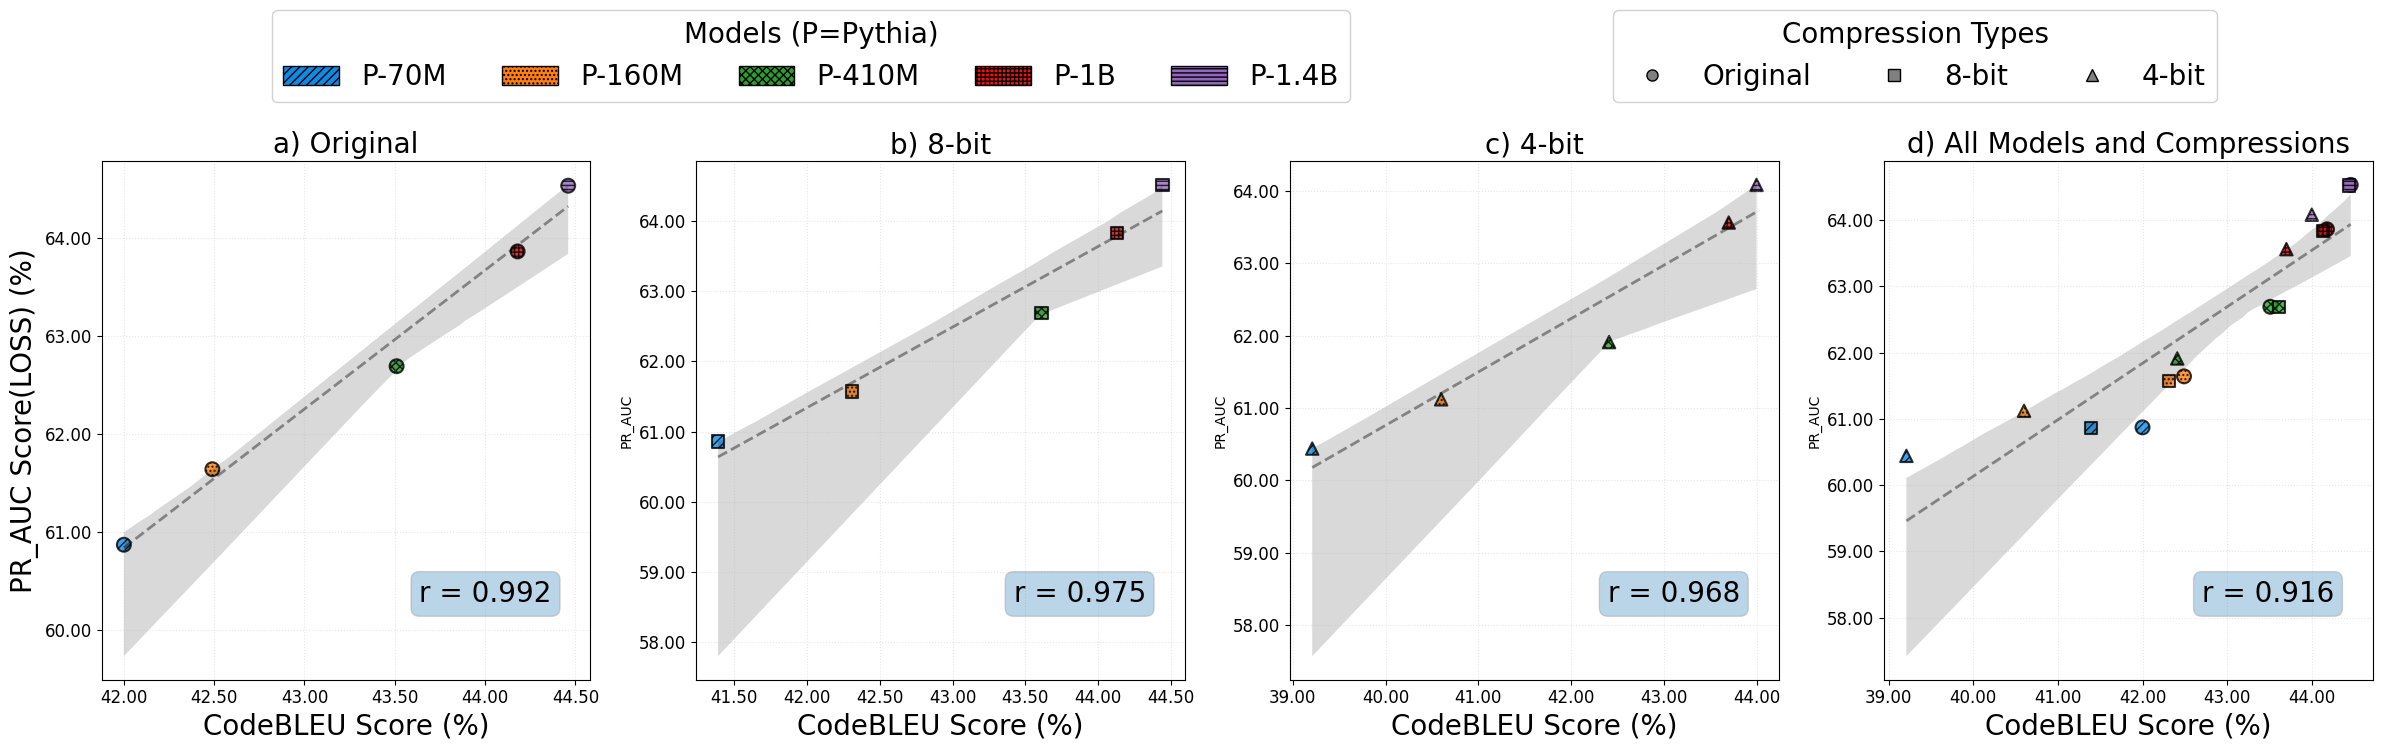

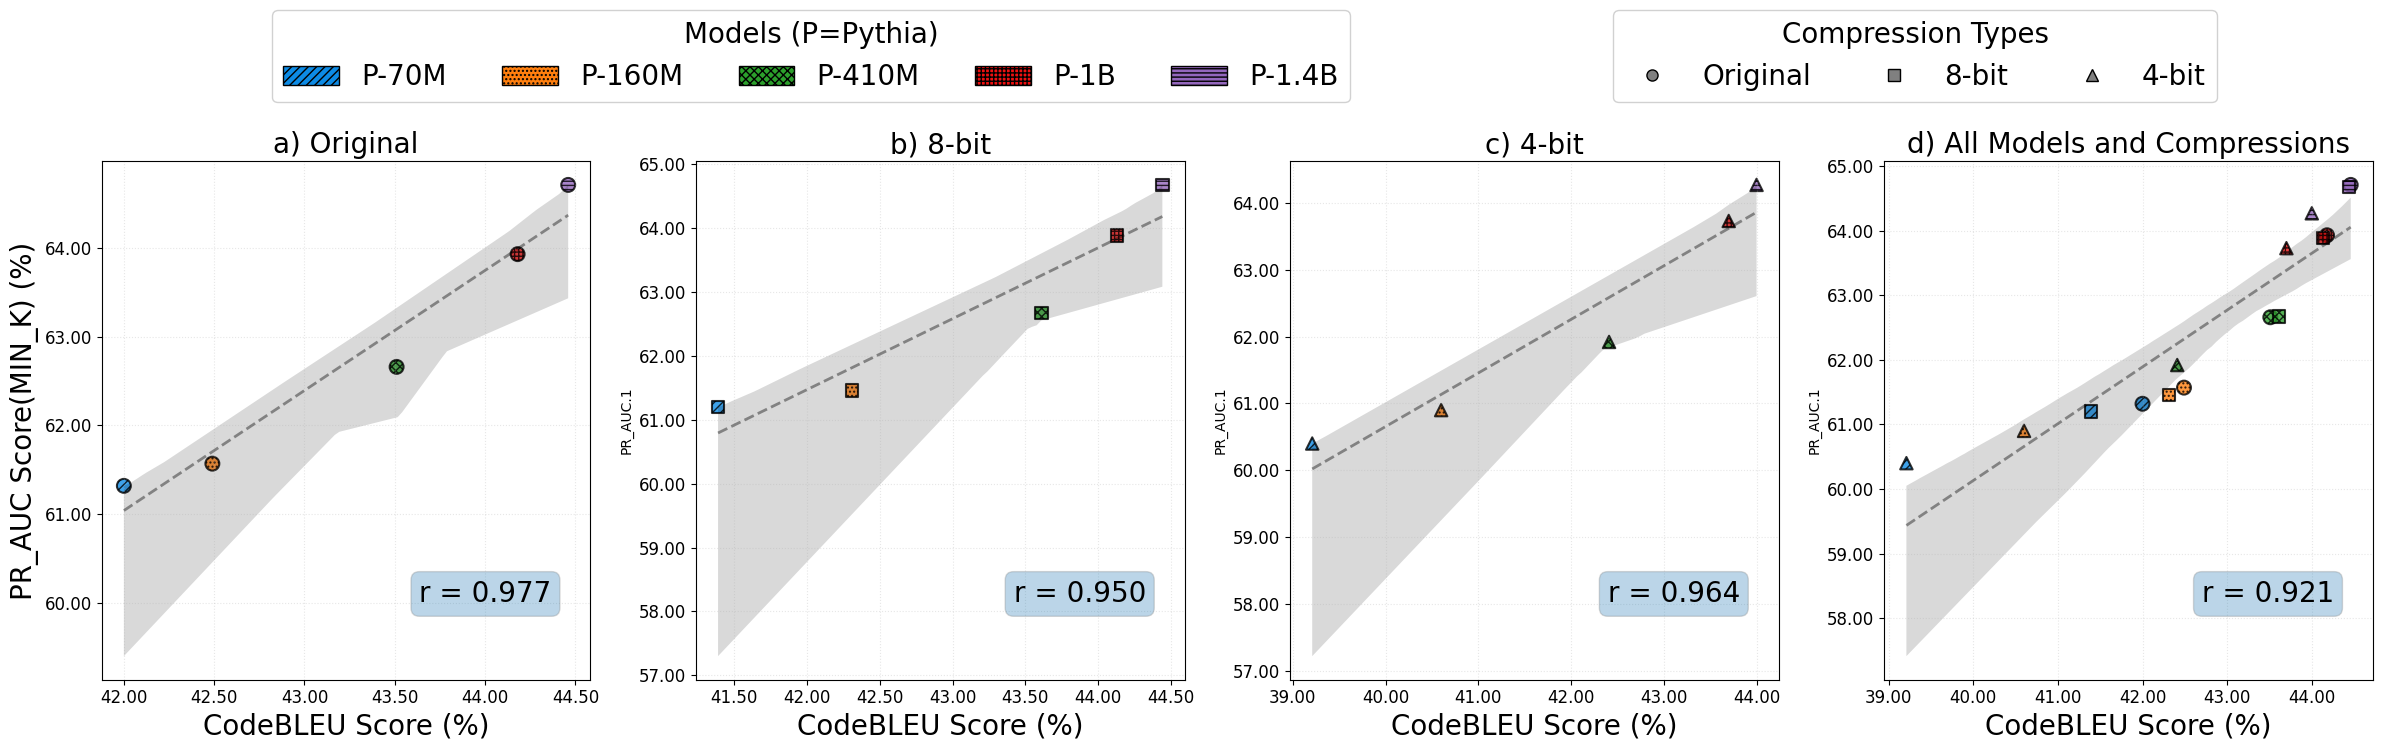

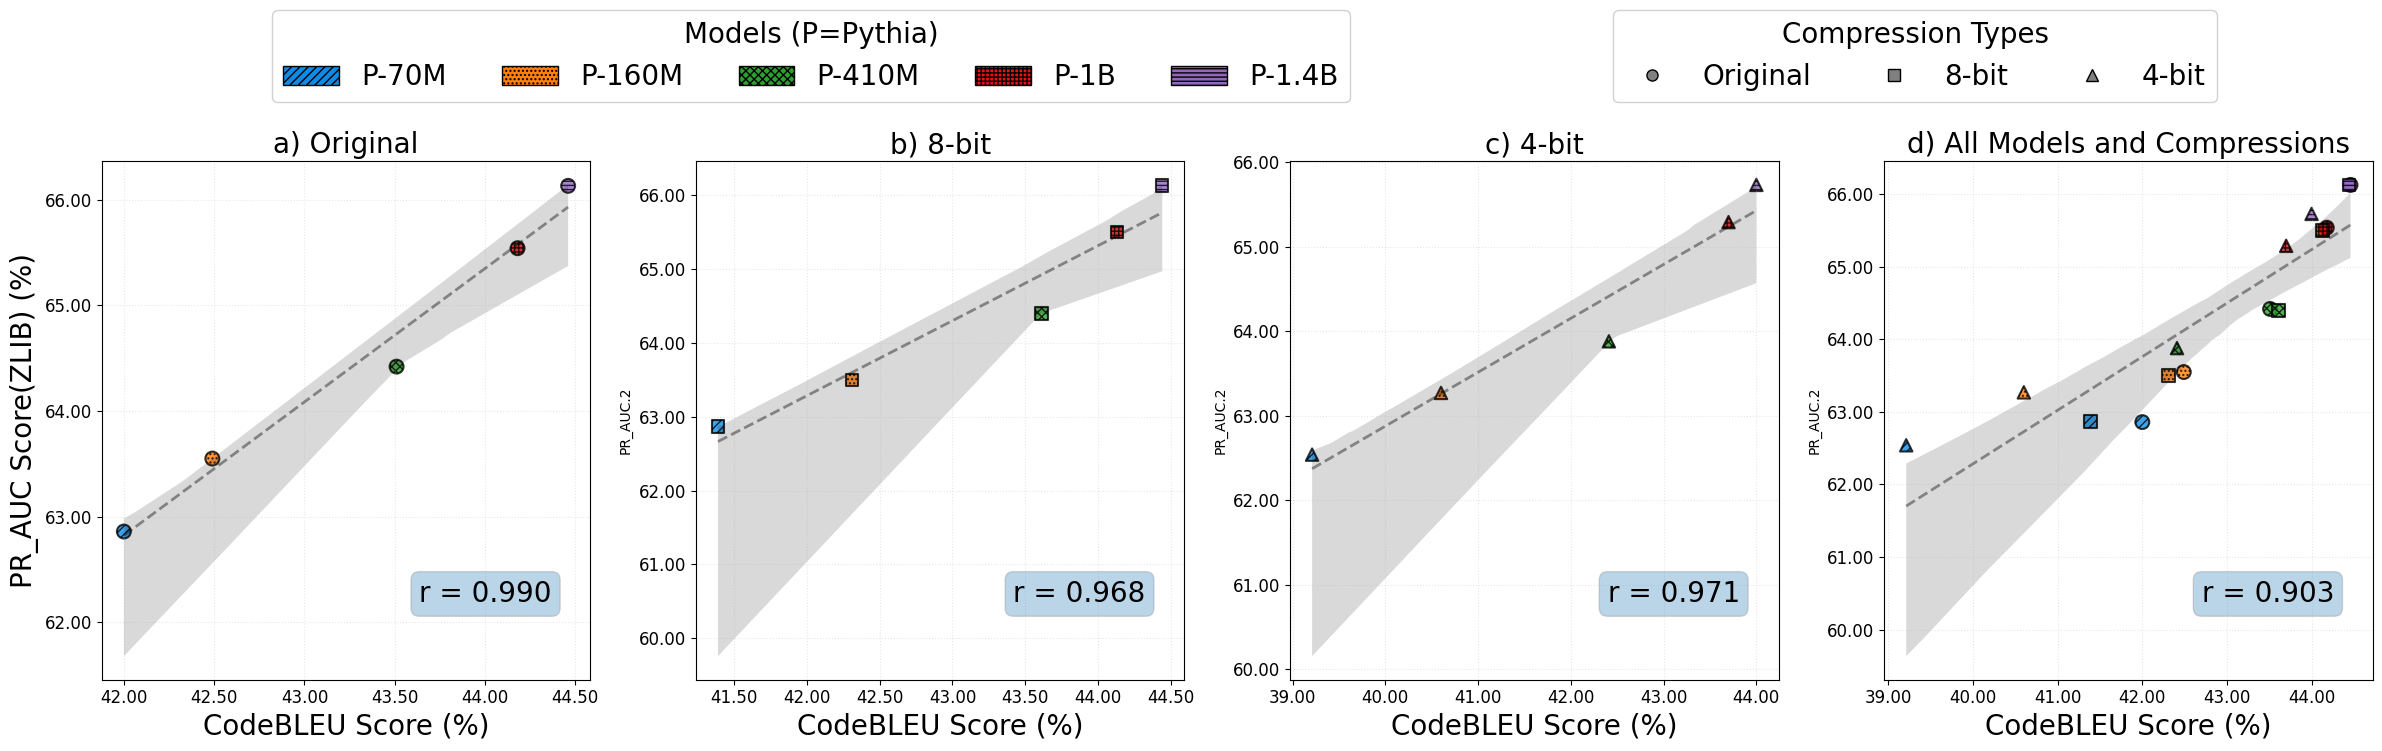

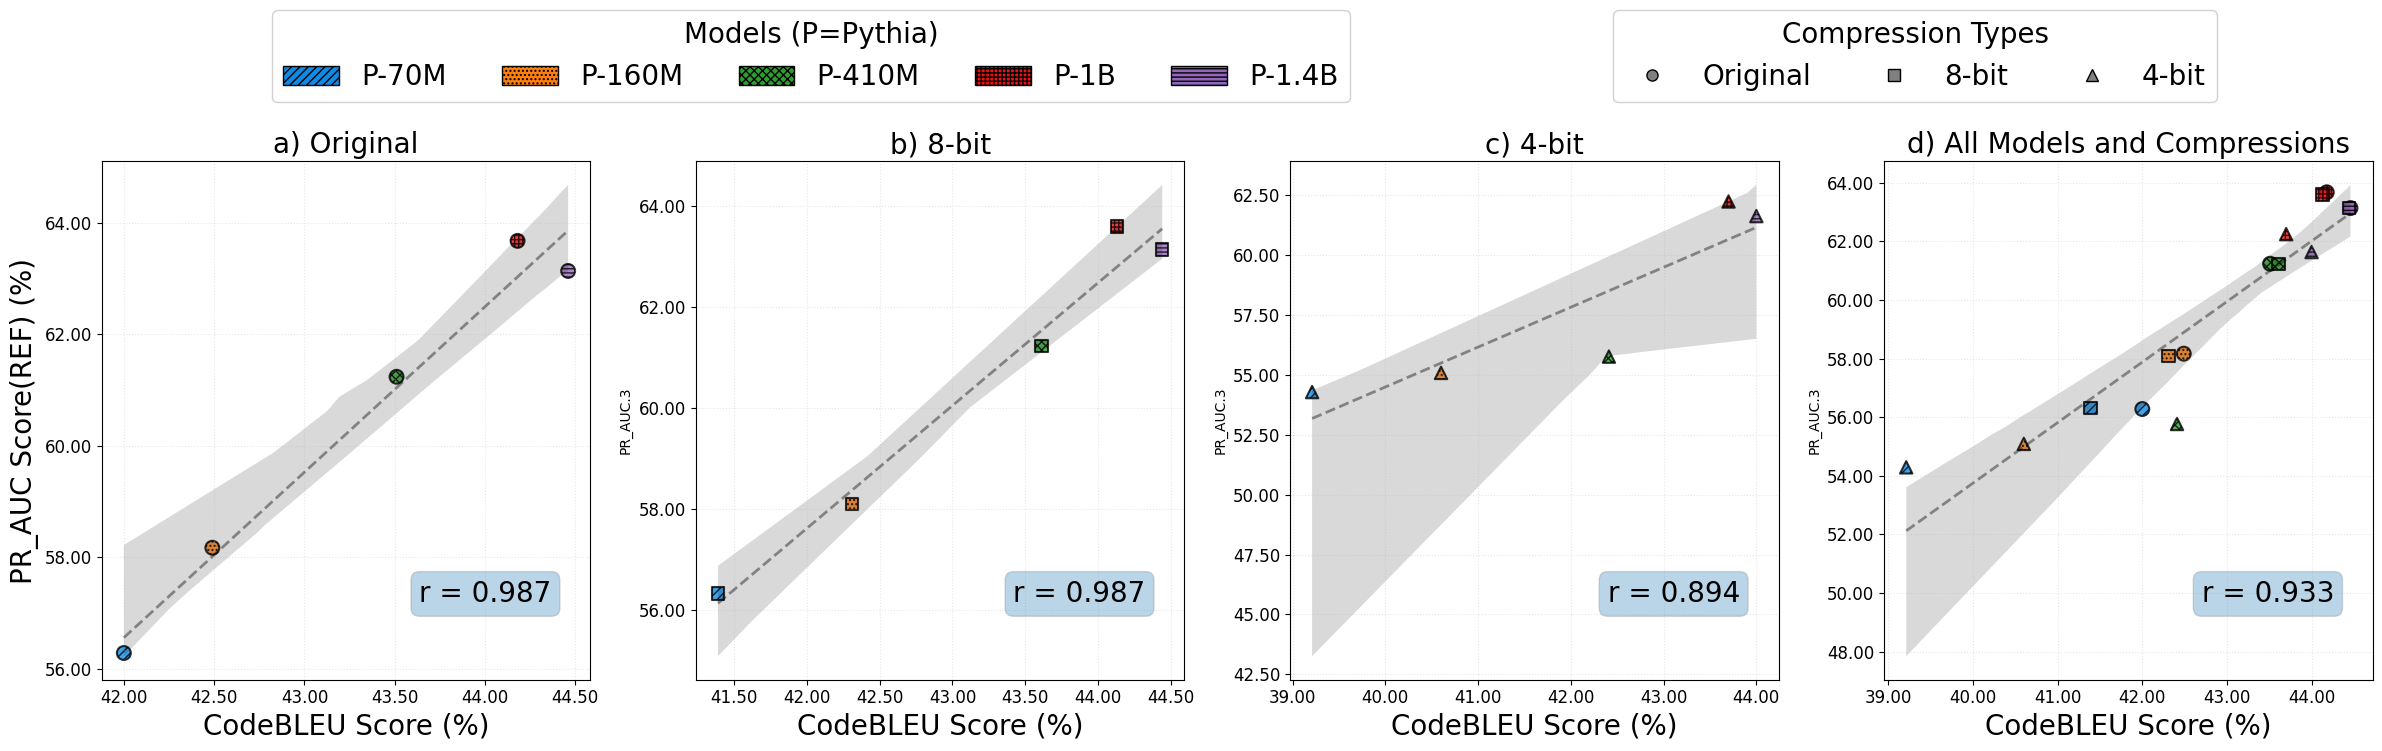

In [3]:
taskPerformance = "BLEU"
MIA_attacks = ["LOSS", "MIN_K", "ZLIB", "REF"]
MIA_scores = ["ROC_AUC", "ROC_AUC.1", "ROC_AUC.2", "ROC_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=1):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)


MIA_scores = ["PR_AUC", "PR_AUC.1", "PR_AUC.2", "PR_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=5):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)

### old part

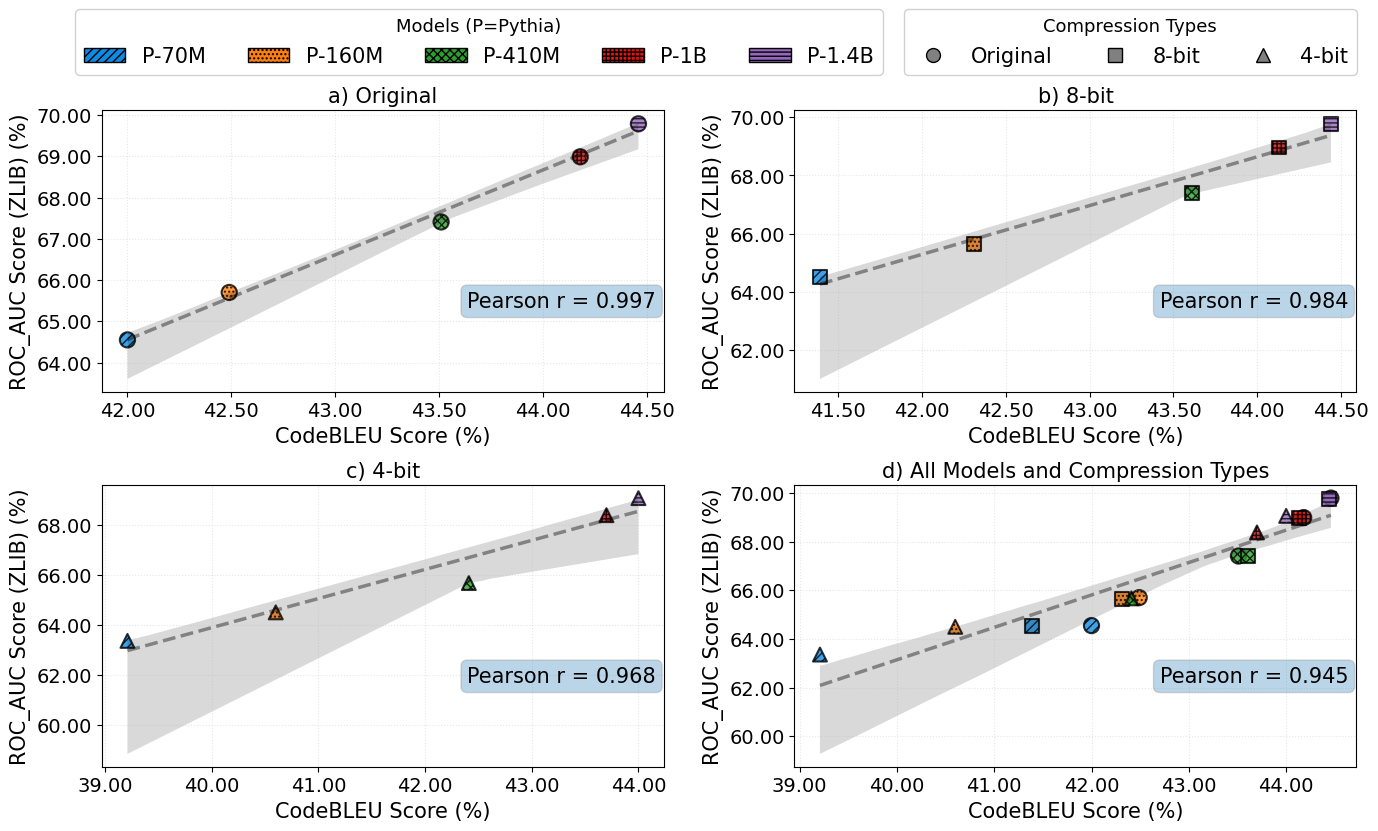

In [4]:
def generate_graphs(taskPerformance, MIA_attack, MIA_score, i):
    # Define styles
    model_order = ['pythia-70M', 'pythia-160M', 'pythia-410M', 'pythia-1B', 'pythia-1.4B']
    short_names = {
        'pythia-70M': 'P-70M',
        'pythia-160M': 'P-160M',
        'pythia-410M': 'P-410M',
        'pythia-1B': 'P-1B',
        'pythia-1.4B': 'P-1.4B'
    }

    # Color scheme and patterns for models
    model_styles = {
        'pythia-70M': {'color': "#0d8be5", 'pattern': '////'},
        'pythia-160M': {'color': "#ff7f0e", 'pattern': '....'},
        'pythia-410M': {'color': "#2ca02c", 'pattern': 'xxxx'},
        'pythia-1B': {'color': "#ef1010", 'pattern': '++++'},
        'pythia-1.4B': {'color': "#9467bd", 'pattern': '----'}
    }
    
    # Marker styles by compression type
    compression_markers = {
        'Original': {'marker': 'o', 'size': 120},
        '8-bit': {'marker': 's', 'size': 100},
        '4-bit': {'marker': '^', 'size': 100}
    }
    
    compression_order = ['Original', '8-bit', '4-bit']
    serials = ['a)', 'b)', 'c)']
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    plt.subplots_adjust(top=0.82, hspace=0.3, wspace=0.3)
    axs = axes.flatten()
    axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
    axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
    axs[2].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
    axs[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    axs[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    axs[2].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    axs[3].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
    axs[3].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    axs[0].tick_params(axis='x', labelsize=14)
    axs[0].tick_params(axis='y', labelsize=14)
    axs[1].tick_params(axis='x', labelsize=14)
    axs[1].tick_params(axis='y', labelsize=14)
    axs[2].tick_params(axis='x', labelsize=14)
    axs[2].tick_params(axis='y', labelsize=14)
    axs[3].tick_params(axis='x', labelsize=14)
    axs[3].tick_params(axis='y', labelsize=14)
    # First three subplots (one per compression type)
    for idx, compression in enumerate(compression_order):
        ax = axs[idx]
        
        # Plot all models with current compression's marker
        for model in model_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                ax.scatter(
                    subset[taskPerformance], subset[MIA_score],
                    c=model_styles[model]['color'],
                    marker=compression_markers[compression]['marker'],
                    s=compression_markers[compression]['size'],
                    alpha=0.8,
                    edgecolors='k',
                    linewidths=1.5,
                    hatch=model_styles[model]['pattern']
                )
        
        # Regression line
        sns.regplot(
            x=taskPerformance, y=MIA_score, 
            data=df[df['Compression'] == compression],
            scatter=False, ci=95,
            ax=ax,
            line_kws={
                'color': 'black', 
                'alpha': 0.4, 
                'linestyle': '--',
                'linewidth': 2.5
            }
        )
        
        # Correlation annotation
        corr = df[df['Compression'] == compression][taskPerformance].corr(
               df[df['Compression'] == compression][MIA_score])
        
        ax.annotate(
            f'Pearson r = {corr:.3f}', 
            xy=(0.65, 0.3), 
            xycoords='axes fraction',
            fontsize=15,
            bbox=dict(boxstyle='round', alpha=0.3, edgecolor='gray')
        )
        
        ax.set_title(f'{serials[idx]} {compression}', fontsize=15)
        ax.set_xlabel('CodeBLEU Score (%)', fontsize=15)
        ax.set_ylabel(f'{MIA_score.split(".")[0]} Score ({MIA_attack}) (%)', fontsize=15)
        ax.grid(True, linestyle=':', alpha=0.3)
    
    # Fourth subplot (all compressions together)
    ax = axs[3]
    for compression in compression_order:
        for model in model_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                ax.scatter(
                    subset[taskPerformance], subset[MIA_score],
                    c=model_styles[model]['color'],
                    marker=compression_markers[compression]['marker'],
                    s=compression_markers[compression]['size'],
                    alpha=0.8,
                    edgecolors='k',
                    linewidths=1.5,
                    hatch=model_styles[model]['pattern'],
                    label=f"{short_names[model]} {compression}"
                )
    
    # Regression line for all data
    sns.regplot(
        x=taskPerformance, y=MIA_score, data=df,
        scatter=False, ci=95,
        ax=ax,
        line_kws={
            'color': 'black', 
            'alpha': 0.4, 
            'linestyle': '--',
            'linewidth': 2.5
        }
    )
    
    # Overall correlation
    corr = df[taskPerformance].corr(df[MIA_score])
    ax.annotate(
        f'Pearson r = {corr:.3f}', 
        xy=(0.65, 0.3), 
        xycoords='axes fraction',
        fontsize=15,
        bbox=dict(boxstyle='round', alpha=0.3, edgecolor='gray')
    )
    
    ax.set_title('d) All Models and Compression Types', fontsize=15)
    ax.set_xlabel('CodeBLEU Score (%)', fontsize=15)

    ax.set_ylabel(f'{MIA_score.split(".")[0]} Score ({MIA_attack}) (%)', fontsize=15)
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # Create legends
    model_legend_elements = [
        plt.Rectangle(
            (0,0), 1, 1, 
            fc=model_styles[model]['color'],
            hatch=model_styles[model]['pattern'],
            edgecolor='k',
            label=short_names[model]
        ) for model in model_order
    ]
    
    compression_legend_elements = [
        Line2D(
            [0], [0], 
            marker=compression_markers[comp]['marker'], 
            color='w',
            markerfacecolor='gray',
            markersize=10,
            markeredgecolor='k',
            label=comp
        ) for comp in compression_order
    ]
    
    # Position legends
    fig.legend(
        handles=model_legend_elements,
        title='Models (P=Pythia)',
        loc='upper left',
        bbox_to_anchor=(0.05, 0.93),
        ncol=5,
        fontsize=15,
        title_fontsize=13,
        framealpha=0.9
    )
    
    fig.legend(
        handles=compression_legend_elements,
        title='Compression Types',
        loc='upper right',
        bbox_to_anchor=(.98, 0.93),
        ncol=3,
        fontsize=15,
        title_fontsize=13,
        framealpha=0.9
    )
    
    # Save and close
    plt.tight_layout(rect=[0, 0, 1, 0.85])
    plt.savefig(f'./output/RQ3.{i}.pdf', dpi=350, bbox_inches='tight')
    plt.show()
    plt.close()
generate_graphs("BLEU", "ZLIB", "ROC_AUC", 3)